In [1]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *

In [2]:
# df_btc_price = pd.read_csv(rf"/home/baia/z/git/data-science-analytics/TCC/data/dados_btc/raw/price_btc.csv")
df_btc_price = pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_btc/raw/price_btc.csv")
df_btc_price['Data_UTC'] = pd.to_datetime(df_btc_price['time'], unit='s', utc=True,).dt.strftime("%Y-%m-%d")

df_sp500 = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/2014_SP500_PRICE.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)

df_vix = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/201501_VIX.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_vix

df_us10y = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/201501_US10Y.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_us10y

,Data_UTC,close_price
0,2000-07-17,6.152
1,2000-07-18,6.146
2,2000-07-19,6.165
3,2000-07-20,6.013
4,2000-07-24,6.031
...,...,...
5793,2025-11-03,4.108
5794,2025-11-04,4.083
5795,2025-11-05,4.161
5796,2025-11-06,4.087


In [3]:
# Base dataframe
df_final = df_periodo.copy()

# Left join com df_btc_price
df_final = df_final.merge(
    df_btc_price[['Data_UTC', 'close']],
    on='Data_UTC',
    how='left'
).rename(columns={
    'close': 'btc_close'
})

# Left join com df_sp500
df_final = df_final.merge(
    df_sp500,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'sp500_close'})

# Left join com df_vix
df_final = df_final.merge(
    df_vix,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'vix_close'})

# Left join com df_us10y
df_final = df_final.merge(
    df_us10y,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'us10y_close'})

df_final = df_final.ffill().query("Data_UTC >= '2017-01-03'").reset_index(drop=True)

df_final = df_final.assign(Data_UTC=pd.to_datetime(df_final['Data_UTC']))

df_final

,Data_UTC,is_weekend,btc_close,sp500_close,vix_close,us10y_close
0,2017-01-03,0,1032.29750,2257.83,12.85,2.4472
1,2017-01-04,0,1130.39975,2270.75,11.85,2.4413
2,2017-01-05,0,1005.64250,2269.00,11.67,2.3479
3,2017-01-06,0,894.70325,2276.98,11.32,2.4221
4,2017-01-07,1,907.65000,2276.98,11.32,2.4221
...,...,...,...,...,...,...
3128,2025-07-28,0,118085.05000,6389.76,15.04,4.3240
3129,2025-07-29,0,117940.69000,6370.87,15.97,4.3720
3130,2025-07-30,0,117815.05000,6362.89,15.47,4.3820
3131,2025-07-31,0,115760.52000,6339.38,16.71,4.2160


In [4]:
mapa_nomes = {
    'btc_close': 'Bitcoin (USD)',
    'sp500_close': 'S&P 500 (Pts)',
    'vix_close': 'VIX (Índice)',
    'us10y_close': 'Treasury 10Y (%)'
}

cols_reais = [c for c in df_final.columns if c in ['btc_close', 'sp500_close', 'vix_close', 'us10y_close']]

tabela_desc = df_final[cols_reais].describe().T[['mean', 'std', 'min', 'max']]
tabela_desc = tabela_desc.rename(index=mapa_nomes)

print(">>> TABELA 1: ESTATÍSTICA DESCRITIVA <<<")
print(tabela_desc)

>>> TABELA 1: ESTATÍSTICA DESCRITIVA <<<
                          mean           std        min         max
Bitcoin (USD)     30104.655643  28548.694672   785.9935  120008.720
S&P 500 (Pts)      3827.475254   1098.218852  2237.4000    6389.760
VIX (Índice)         18.782068      7.613974     9.1400      82.690
Treasury 10Y (%)      2.725600      1.189180     0.5100       4.992


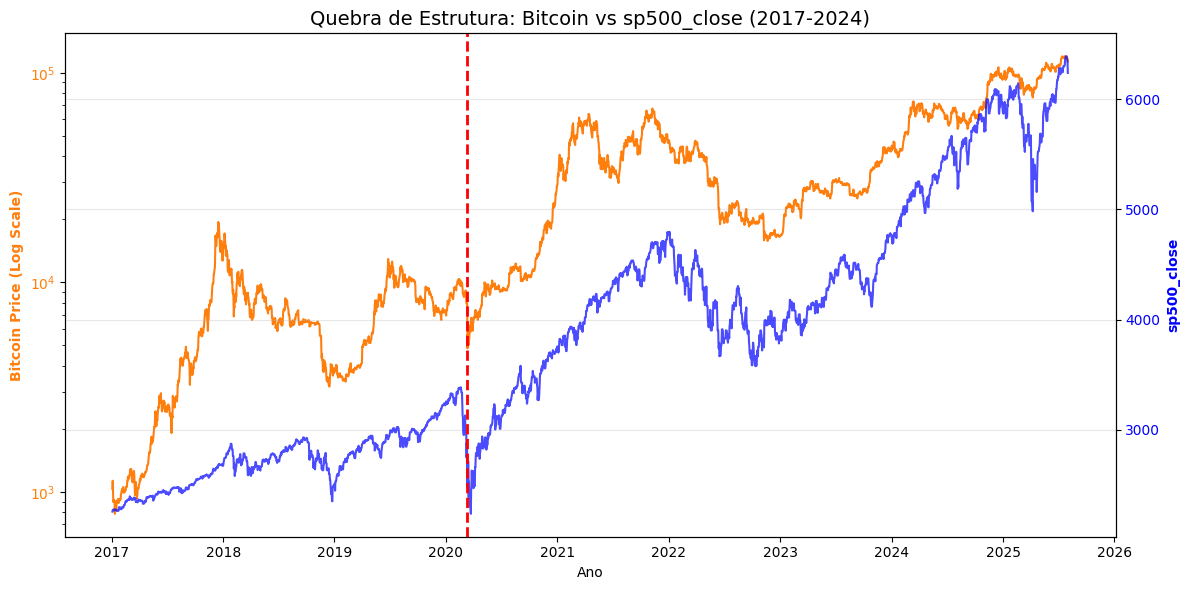

In [35]:
nome_macro = 'sp500_close'
fig, ax1 = plt.subplots(figsize=(12, 6))


# Eixo Esquerda (Bitcoin)
color = 'tab:orange'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Bitcoin Price (Log Scale)', color=color, fontweight='bold')
ax1.plot(df_final['Data_UTC'], df_final['btc_close'], color=color, label='Bitcoin', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log') # Escala Log ajuda a visualizar melhor o BTC longo prazo

# Eixo Direita (Macro)
ax2 = ax1.twinx()
ax2.set_ylabel(nome_macro, color='blue', fontweight='bold')
ax2.plot(df_final['Data_UTC'], df_final[nome_macro], color='blue', label=nome_macro, linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor='blue')

# Linha da Quebra Estrutural
plt.axvline(pd.to_datetime(DATA_DIVISAO_ERA), color='red', linestyle='--', linewidth=2, label='Início Era Institucional')

# Título e Layout
plt.title(f'Quebra de Estrutura: Bitcoin vs {nome_macro} (2017-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

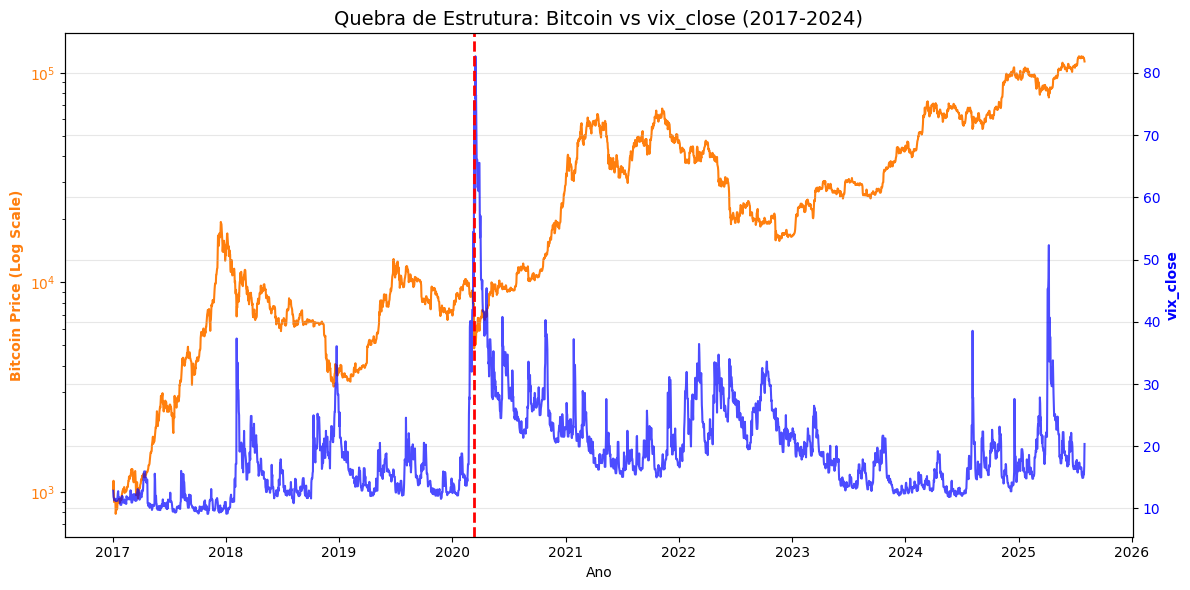

In [37]:
nome_macro = 'vix_close'
fig, ax1 = plt.subplots(figsize=(12, 6))


# Eixo Esquerda (Bitcoin)
color = 'tab:orange'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Bitcoin Price (Log Scale)', color=color, fontweight='bold')
ax1.plot(df_final['Data_UTC'], df_final['btc_close'], color=color, label='Bitcoin', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log') # Escala Log ajuda a visualizar melhor o BTC longo prazo

# Eixo Direita (Macro)
ax2 = ax1.twinx()
ax2.set_ylabel(nome_macro, color='blue', fontweight='bold')
ax2.plot(df_final['Data_UTC'], df_final[nome_macro], color='blue', label=nome_macro, linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor='blue')

# Linha da Quebra Estrutural
plt.axvline(pd.to_datetime(DATA_DIVISAO_ERA), color='red', linestyle='--', linewidth=2, label='Início Era Institucional')

# Título e Layout
plt.title(f'Quebra de Estrutura: Bitcoin vs {nome_macro} (2017-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

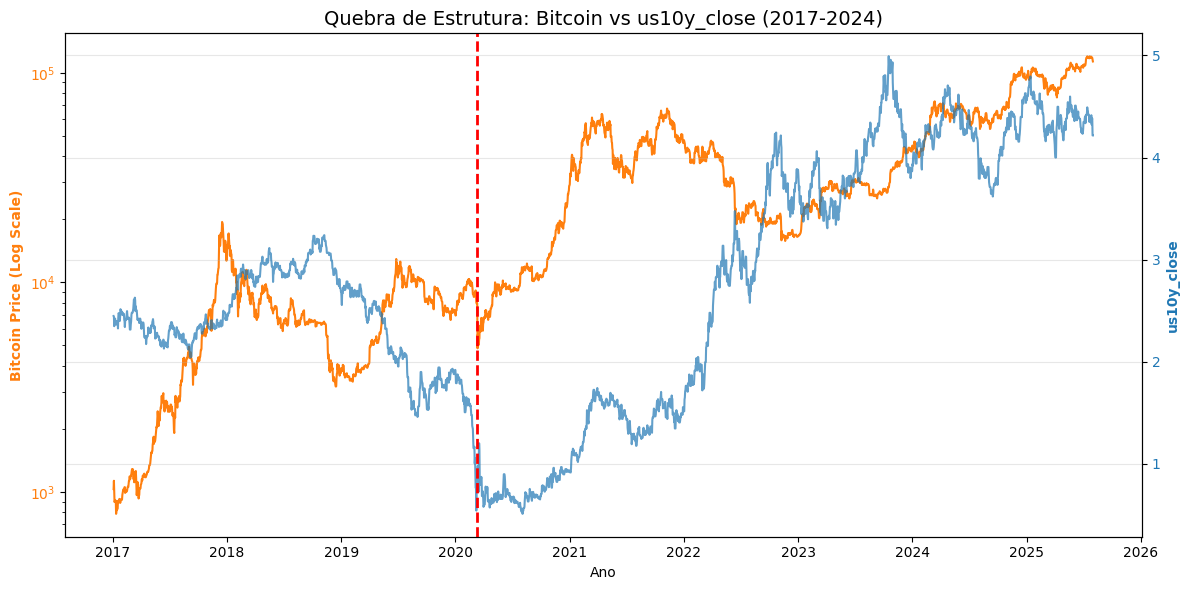

In [ ]:
nome_macro = 'us10y_close'
fig, ax1 = plt.subplots(figsize=(12, 6))


# Eixo Esquerda (Bitcoin)
color = 'tab:orange'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Bitcoin Price (Log Scale)', color=color, fontweight='bold')
ax1.plot(df_final['Data_UTC'], df_final['btc_close'], color=color, label='Bitcoin', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log') # Escala Log ajuda a visualizar melhor o BTC longo prazo

# Eixo Direita (Macro)
color2 = 'tab:blue'
ax2 = ax1.twinx()
ax2.set_ylabel(nome_macro, color=color2, fontweight='bold')
ax2.plot(df_final['Data_UTC'], df_final[nome_macro], color=color2, label=nome_macro, linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color2)
# Linha da Quebra Estrutural
plt.axvline(pd.to_datetime(DATA_DIVISAO_ERA), color='red', linestyle='--', linewidth=2, label='Início Era Institucional')

# Título e Layout 
plt.title(f'Quebra de Estrutura: Bitcoin vs {nome_macro} (2017-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()